## Exercise 4a ##

average spike rate: 4.20 spikes per second
average spike rate: 4.45 spikes per second
average spike rate: 4.72 spikes per second
average spike rate: 4.63 spikes per second
average spike rate: 4.66 spikes per second


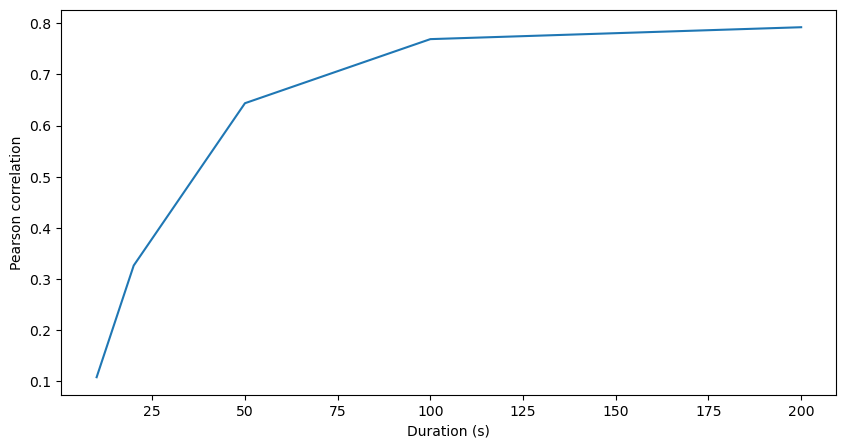

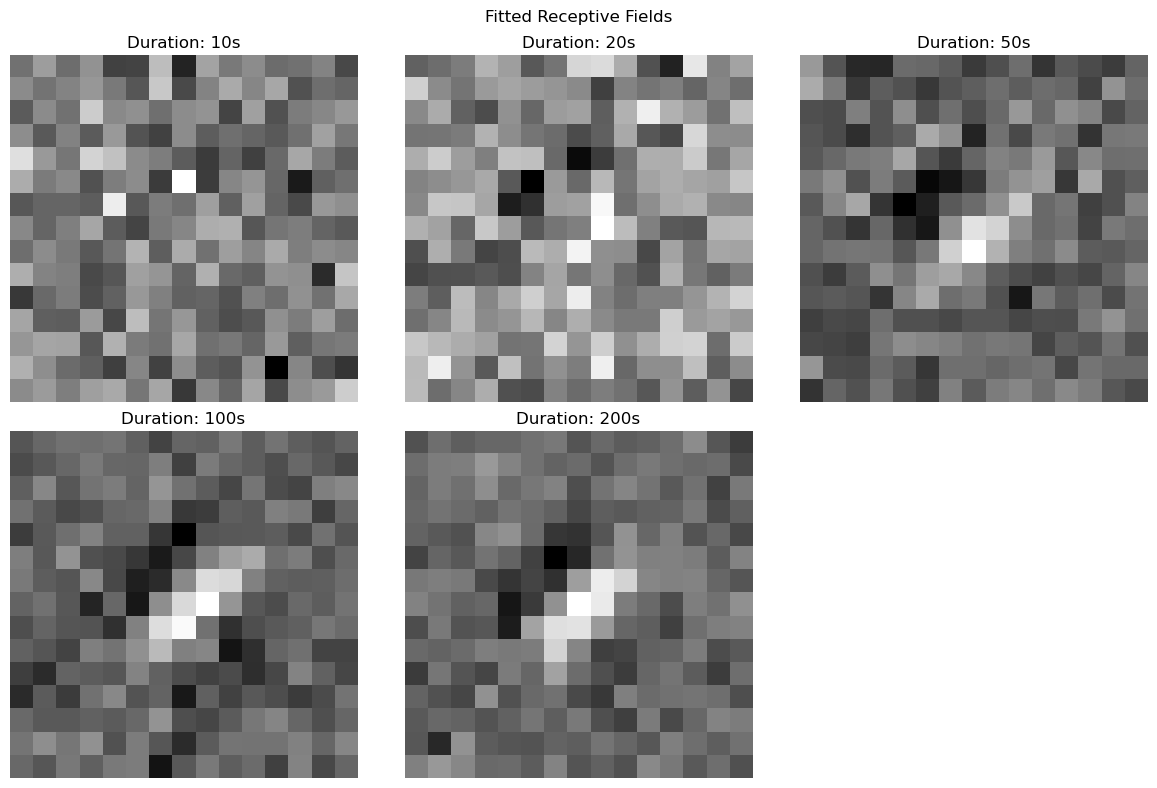

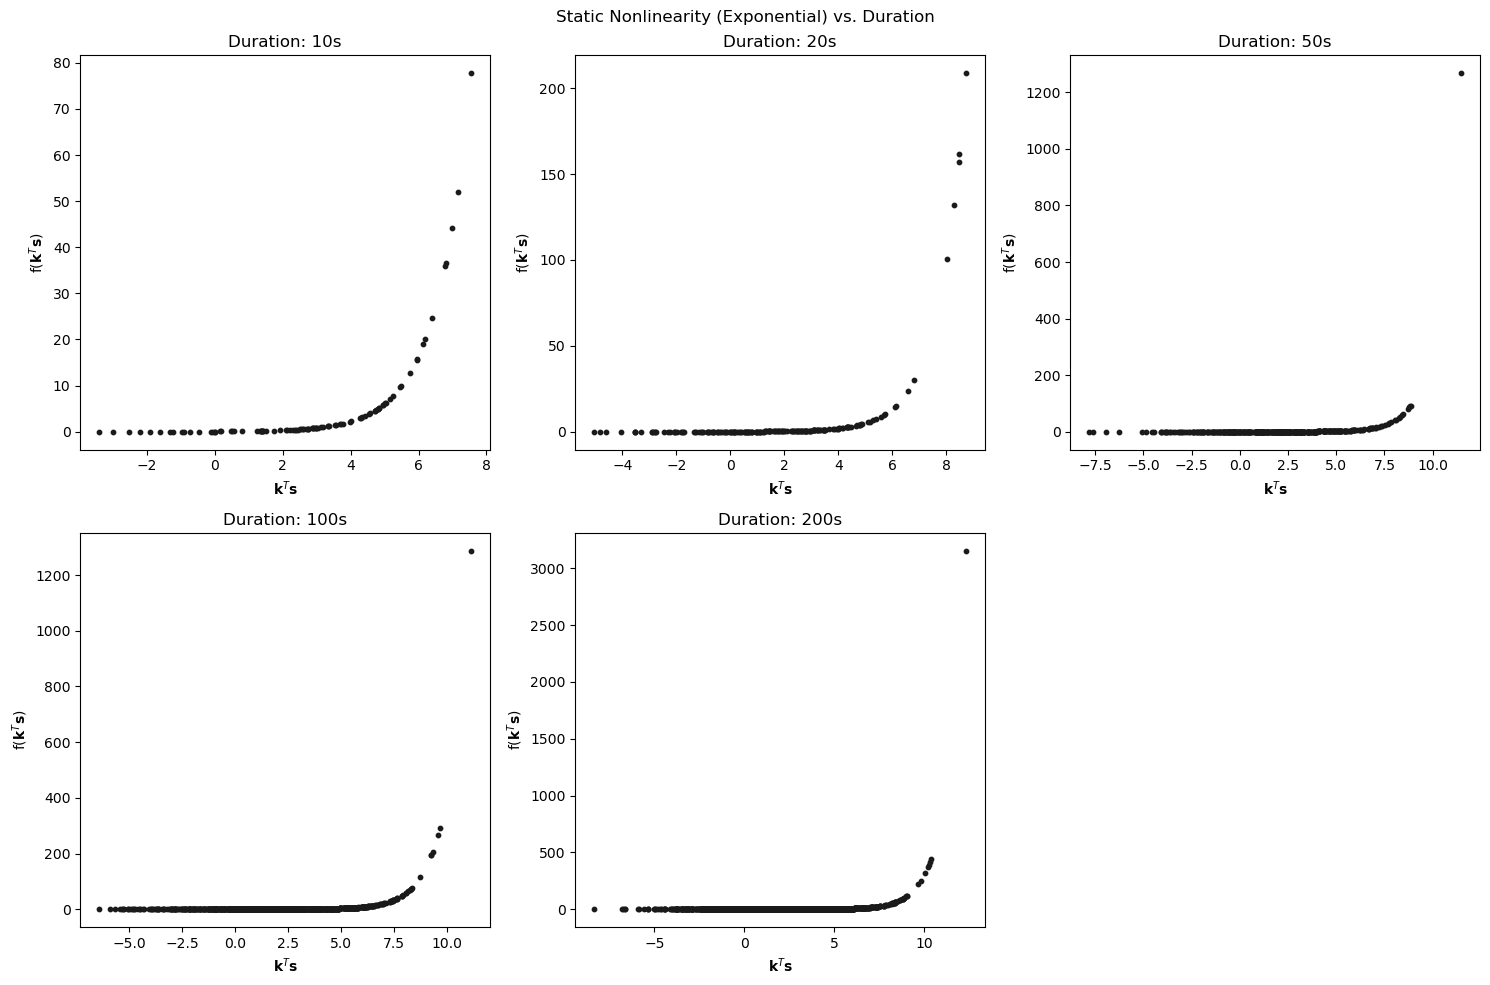

In [1]:
# Most code is from the lecture material
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# generation of the stimulus
dt = .1
std_dev = 1
vf_size = (15,15)
spike_rate = 5 # average firing rate
offset = 2.

## create receptive field with gabor patch
size = vf_size # size in pixel of our receptive field
mu = (8, 8) # center of the gabor pathc
sigma = (4,4) #size of the gabor patch
angle = 45 # orientation of the gabor patch
frequency = .085 # spatial frequency of the gabor patch
phase = 0 # pahse of the gabor pathc


xx, yy = np.meshgrid(1. + np.arange(size[0]),
                         1. + np.arange(size[1]))

# Gaussian envelope
G = np.exp(- np.power(xx - mu[0], 2) / (2. * sigma[0])
            - np.power(yy - mu[1], 2) / (2. * sigma[1]))

# spatial modulation
phi = np.deg2rad(angle)
xxr = xx * np.cos(phi)
yyr = yy * np.sin(phi)
xyr = (xxr + yyr) * 2. * np.pi * 2. * frequency
Sn = np.cos(xyr + phase)

K = G * Sn
K /= np.amax(np.abs(K))

## spike generator
def generate_inhomogenous_poisson_spikes(lamda, dt):

    n_bins = lamda.shape[0]
    bins = np.arange(n_bins+1)*dt

    #generate Poisson distributed nu,bers for all bins with the max. intensity (lamda_max)
    lamda_max = np.max(lamda)
    poisson_numbers = np.random.poisson(lamda_max, size=n_bins)

    # throw away numbers depending ont he actual intensity ("thinning")
    spike_times = []
    prob = lamda / lamda_max
    for i in range(n_bins):

        # number of spikes to keep in this bin
        n = np.sum(np.random.rand(poisson_numbers[i]) < prob[i])
        n_s = int(round(n * dt))
        
        # generate random spike times i this bin
        ts = bins[i] + np.random.rand(n_s)*dt

        spike_times.extend(ts)

    return np.asarray(spike_times)

## minimisation functions
def cost(k, spike_counts, S,alpha=1):
    #negative loglikelihood function to minimize
    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(spike_counts, ks) + dt * np.sum(lamda)
    
    
def grad(k, spike_counts, S):
    # expression of the gradient of the negative log likelihood (note the sign is flipped accordingly)

    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(S.T, spike_counts - dt*lamda)

##
durations = [10,20,50,100,200]
pearson_correlations = []
K_est_values = []
ks_values = []
lamda_values = []

# for loop iterating over the durations, calculating the pearson corealtion
for duration in durations:
    n_bins = round(duration / float(dt))
    S = std_dev * np.random.randn(n_bins, vf_size[0], vf_size[1])
    
    # flatten the matrices into 1d array for convenience
    K_flat = K.ravel()
    K_flat = np.hstack((K.flat, offset))
    
    S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
    S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))
    
    # 1. linear stage
    ks = np.dot(K_flat, S_flat.T)
    
    # 2. nonlinear stage (for a linear model: f -> identity function)
    lamda = np.exp(ks)
    
    # lamda * dt is the number of spikes in the different bins (but keep in mind that the Poisson process is a stochastic process so the actual numver will differ for every draw. Thus, the sum of the product across all bins gives the expected number of spikes for the whole draw.
    expected_rate = np.sum(lamda*dt) / duration
    lamda *= (spike_rate/ expected_rate)
    
    # generate spike times using an inhomogenous Poisson process
    spike_times = generate_inhomogenous_poisson_spikes(lamda, dt)
    
    # compute spike counts in the different time bins
    spike_counts = np.histogram(spike_times, bins=np.arange(n_bins+1)*dt)[0]
    
    print("average spike rate: %0.2f spikes per second" % (len(spike_times) / duration))

    k_STA = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
    res = minimize(fun = cost, x0 = k_STA / 10, args = (spike_counts, S_flat), method = 'Newton-CG', jac = grad)

    K_est = res.x
    p_corr = np.inner(K.ravel(), K_est[:-1]) / (np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1]))
    pearson_correlations.append(p_corr)
    K_est_values.append(K_est)
    ks_values.append(ks)
    lamda_values.append(lamda)
    
# plt p corr against time
plt.figure(figsize=(10,5))
plt.plot(durations, pearson_correlations)
plt.xlabel('Duration (s)')
plt.ylabel('Pearson correlation')
plt.show()

# plot fitted receptive fields
plt.figure(figsize=(12, 8))
for i, duration in enumerate(durations):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns (for 5 durations)
    plt.imshow(K_est_values[i][:-1].reshape(15, 15), cmap='gray')
    plt.title(f'Duration: {duration}s')
    plt.axis('off')
plt.suptitle('Fitted Receptive Fields')
plt.tight_layout()
plt.show()

# plot lamda and ks per duration
plt.figure(figsize=(15, 10))
for i, duration in enumerate(durations):
    plt.subplot(2, 3, i + 1)
    plt.scatter(ks_values[i], lamda_values[i], s=10, c=[3*[.1]])
    plt.xlabel(r'$\mathbf{k}^T \mathbf{s}$')
    plt.ylabel(r'f($\mathbf{k}^T \mathbf{s}$)')
    plt.title(f'Duration: {duration}s')

plt.suptitle('Static Nonlinearity (Exponential) vs. Duration')
plt.tight_layout()
plt.show()

## Comment ##
Generally, the goodness of the fit increases with increasing duration (higher pearson coreelation, the more similar Kest and Ktrue). Longer duration gives more data, reducing noise and thereby increasing accuracy of the fit.
With increasing duration, the fitted receptive fields become clearer

## Exercise 4B

average spike rate: 0.86 spikes per second
average spike rate: 4.57 spikes per second
average spike rate: 9.60 spikes per second
average spike rate: 19.49 spikes per second
average spike rate: 49.39 spikes per second


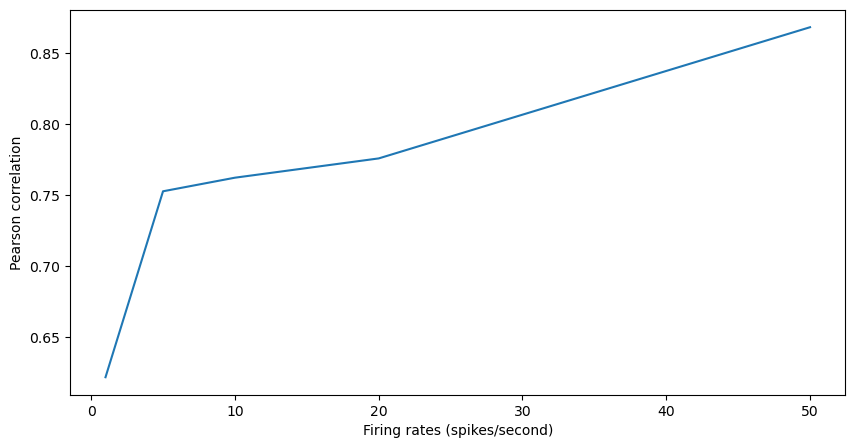

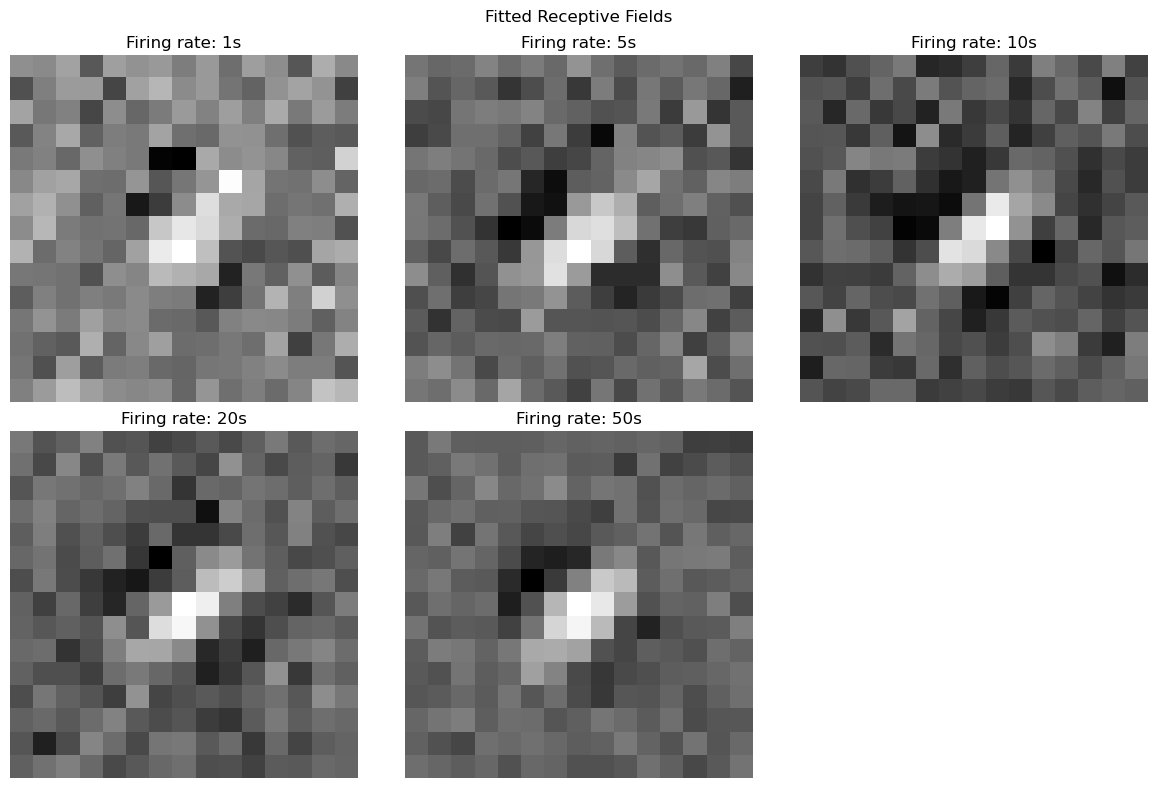

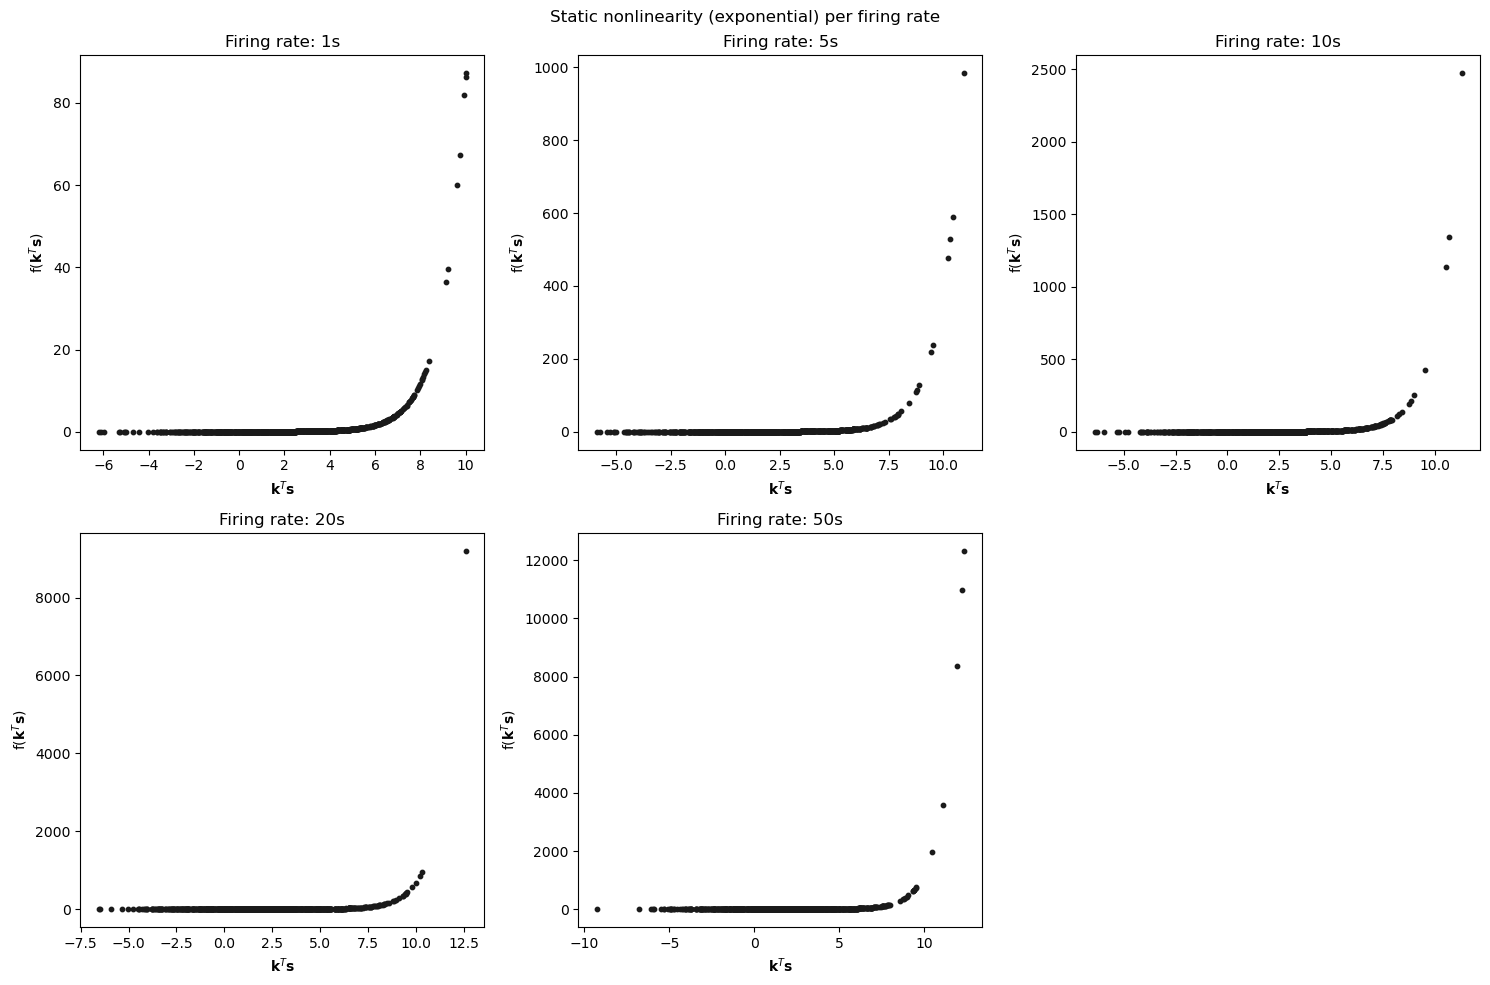

In [2]:
# I removed all code on creating the receptive field and the defined functions, so this snippet uses that from exercise 4A. the difference is that durations is now only 100 and firing rates is an array of arbitrarily chosen values
duration = 100

## 
firing_rates = [1,5,10,20,50]
pearson_correlations = []
K_est_values = []
ks_values = []
lamda_values = []

# for loop iterating over the durations, calculating the pearson corealtion
for spike_rate in firing_rates:
    n_bins = round(duration / float(dt))
    S = std_dev * np.random.randn(n_bins, vf_size[0], vf_size[1])
    
    # flatten the matrices into 1d array for convenience
    K_flat = K.ravel()
    K_flat = np.hstack((K.flat, offset))
    
    S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
    S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))
    
    # 1. linear stage
    ks = np.dot(K_flat, S_flat.T)
    
    # 2. nonlinear stage (for a linear model: f -> identity function)
    lamda = np.exp(ks)
    
    # lamda * dt is the number of spikes in the different bins (but keep in mind that the Poisson process is a stochastic process so the actual numver will differ for every draw. Thus, the sum of the product across all bins gives the expected number of spikes for the whole draw.
    expected_rate = np.sum(lamda*dt) / duration
    lamda *= (spike_rate/ expected_rate)
    
    # generate spike times using an inhomogenous Poisson process
    spike_times = generate_inhomogenous_poisson_spikes(lamda, dt)
    
    # compute spike counts in the different time bins
    spike_counts = np.histogram(spike_times, bins=np.arange(n_bins+1)*dt)[0]
    
    print("average spike rate: %0.2f spikes per second" % (len(spike_times) / duration))

    k_STA = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
    res = minimize(fun = cost, x0 = k_STA / 10, args = (spike_counts, S_flat), method = 'Newton-CG', jac = grad)

    K_est = res.x
    p_corr = np.inner(K.ravel(), K_est[:-1]) / (np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1]))
    pearson_correlations.append(p_corr)
    K_est_values.append(K_est)
    ks_values.append(ks)
    lamda_values.append(lamda)

# plt pearsonsn correlation agaisnt duration
plt.figure(figsize=(10,5))
plt.plot(firing_rates, pearson_correlations)
plt.xlabel('Firing rates (spikes/second)')
plt.ylabel('Pearson correlation')
plt.show()

# plot receptive fields per firing rate
plt.figure(figsize=(12, 8))
for i, spike_rate in enumerate(firing_rates):
    plt.subplot(2, 3, i + 1)
    plt.imshow(K_est_values[i][:-1].reshape(15, 15), cmap='gray')
    plt.title(f'Firing rate: {spike_rate}s')
    plt.axis('off')
plt.suptitle('Fitted Receptive Fields')
plt.tight_layout()
plt.show()

# plot lamda and ks per firing rate
plt.figure(figsize=(15, 10))
for i, spike_rate in enumerate(firing_rates):
    plt.subplot(2, 3, i + 1)
    plt.scatter(ks_values[i], lamda_values[i], s=10, c=[3*[.1]])
    plt.xlabel(r'$\mathbf{k}^T \mathbf{s}$')
    plt.ylabel(r'f($\mathbf{k}^T \mathbf{s}$)')
    plt.title(f'Firing rate: {spike_rate}s')

plt.suptitle('Static nonlinearity (exponential) per firing rate')
plt.tight_layout()
plt.show()

## Comment ##
With increasing firing rates, the pearson correlation becomes higher, suggesting a better model fit. With increased firing rates, there are more spikes per time frame, which provides strogner statistical power. Again, the receptive fields become more clear with increasing firing rate